Image saved as road.jpg
Displaying final output...


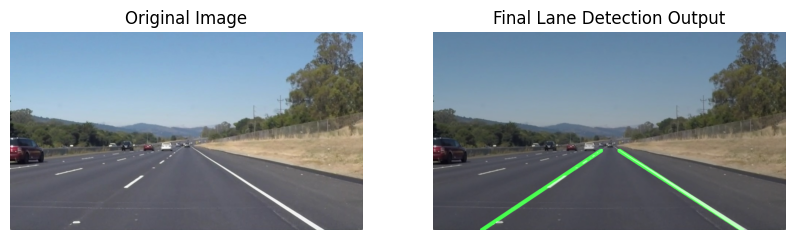

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os # Import os to check if file exists

## ----------------- CORE IMPLEMENTATION -----------------

def detect_lanes(image_path="road.jpg"):
    """
    Main function to perform lane detection on an image.
    """
    # --- Step 0: Load Image ---
    
    # --- UPDATED URL ---
    # This URL points to the same 'solidWhiteRight.jpg' image in a different repository.
    image_url = 'https://raw.githubusercontent.com/udacity/CarND-LaneLines-P1/master/test_images/solidWhiteRight.jpg'
    # --- END UPDATE ---
    
    try:
        # Download the sample image if it doesn't exist
        if not os.path.exists(image_path):
            print("Downloading sample image...")
            urllib.request.urlretrieve(image_url, image_path)
            print(f"Image saved as {image_path}")

        image = cv2.imread(image_path)
        if image is None:
            raise Exception("Image file not found or could not be read. Please check the path.")
            
        # OpenCV reads images in BGR format, so we convert to RGB for correct display
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
    except Exception as e:
        print(f"Error loading image: {e}")
        print(f"Please provide a valid image path or ensure '{image_path}' can be downloaded from {image_url}")
        return

    # Create copies for visualization
    original_image = np.copy(image)

    # --- Step 1 & 2: Smoothing and Edge Detection (Sections 2.2.1, 2.2.2) ---
    # Convert to grayscale, apply a median blur, and then use Canny edge detection.
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blurred_image = cv2.medianBlur(gray_image, 5) # Median filter as specified
    canny_image = cv2.Canny(blurred_image, 50, 150)

    # --- Step 3: Region of Interest (ROI) (Section 2.3) ---
    # Create a mask to focus only on the road area.
    height, width = canny_image.shape
    
    # Define the vertices of the polygon for the ROI
    # This trapezoid is tuned for the 960x540 sample image
    roi_vertices = np.array([
        [(int(0.1 * width), height),              # Bottom-left
         (int(0.45 * width), int(0.6 * height)), # Top-left
         (int(0.55 * width), int(0.6 * height)), # Top-right
         (int(0.95 * width), height)]             # Bottom-right
    ], dtype=np.int32)
    
    mask = np.zeros_like(canny_image)
    cv2.fillPoly(mask, roi_vertices, 255)
    roi_image = cv2.bitwise_and(canny_image, mask)

    # --- Step 4: Hough Transform (Section 2.3.1) ---
    # Detect lines in the ROI-masked edge image.
    lines = cv2.HoughLinesP(
        roi_image,
        rho=2,              # Distance resolution in pixels
        theta=np.pi/180,    # Angular resolution in radians
        threshold=100,      # Minimum number of votes
        lines=np.array([]), # Placeholder
        minLineLength=40,   # Minimum length of a line
        maxLineGap=5        # Maximum allowed gap between line segments
    )

    # --- Step 5: Post-Processing & Refinement (Section 2.3.2) ---
    # Average and extrapolate lines to create two stable lane lines.
    left_fit = []
    right_fit = []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line.reshape(4)
            # Fit a 1st degree polynomial (a line) to the points
            parameters = np.polyfit((x1, x2), (y1, y2), 1)
            slope, intercept = parameters
            if slope < -0.5: # Negative slope for the left lane
                left_fit.append((slope, intercept))
            elif slope > 0.5: # Positive slope for the right lane
                right_fit.append((slope, intercept))

    # Average the parameters for left and right lanes
    averaged_lines = []
    if left_fit:
        left_fit_average = np.average(left_fit, axis=0)
        averaged_lines.append(make_coordinates(image, left_fit_average))
    
    if right_fit:
        right_fit_average = np.average(right_fit, axis=0)
        averaged_lines.append(make_coordinates(image, right_fit_average))

    # --- Step 6: Visualization ---
    # Draw the final lane lines on a blank image
    line_image = np.zeros_like(original_image)
    if averaged_lines:
        for x1, y1, x2, y2 in averaged_lines:
            cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 10) # Draw green lines

    # Combine the line image with the original image
    final_image = cv2.addWeighted(original_image, 0.8, line_image, 1, 0)
    
    # --- Display Results ---
    print("Displaying final output...")
    plt.figure(figsize=(10, 5))
    
    # Show side-by-side comparison
    plt.subplot(1, 2, 1)
    plt.imshow(original_image)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(final_image)
    plt.title("Final Lane Detection Output")
    plt.axis('off')
    
    plt.show()

def make_coordinates(image, line_parameters):
    """
    Helper function to convert slope and intercept into (x1, y1, x2, y2) coordinates.
    """
    slope, intercept = line_parameters
    height = image.shape[0]
    
    # Define the vertical start and end points for the line
    y1 = height          # Bottom of the image
    y2 = int(y1 * 0.6)   # Top of the ROI
    
    # Calculate the corresponding x values
    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)
    
    return [x1, y1, x2, y2]

## ----------------- RUN THE CODE -----------------
if __name__ == '__main__':
    # You can specify a local path, or leave it to download the default image
    # detect_lanes("my_local_road_image.jpg")
    detect_lanes()